In [ ]:
!pip install pykan

In [ ]:
!pip install ucimlrepo


In [ ]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import layers


In [2]:
energy = fetch_ucirepo(id=242)
print(energy.data)

NameError: name 'fetch_ucirepo' is not defined

In [16]:
x = energy.data.features
y = energy.data.targets

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget ranges:")
print("Y1 (heating) min:", y['Y1'].min(), " max:", y['Y1'].max())
print("Y2 (cooling) min:", y['Y2'].min(), " max:", y['Y2'].max())
print("\nMissing values:", X.isnull().sum().sum())

X shape: (768, 8)
y shape: (768, 2)

Target ranges:
Y1 (heating) min: 6.01  max: 43.1
Y2 (cooling) min: 10.9  max: 48.03

Missing values: 0


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614, 2)
y_test shape: (154, 2)


In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [1]:
# predict only Y1 - heating load
y_train_y1 = y_train['Y1']
y_test_y1 = y_test['Y1']

model = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(8, activation='tanh'),
    layers.Dense(10, activation='tanh'),
    layers.Dense(8, activation='tanh'),
    layers.Dense(4, activation='tanh'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

NameError: name 'y_train' is not defined

In [38]:
history = model.fit(
    X_train_scaled, y_train_y1,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 18.1186 - mae: 2.9327 - val_loss: 20.0731 - val_mae: 3.0430
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 18.1142 - mae: 2.9001 - val_loss: 20.4516 - val_mae: 3.1405
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 17.9958 - mae: 2.8774 - val_loss: 20.1872 - val_mae: 3.0989
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 17.9832 - mae: 2.8682 - val_loss: 20.1718 - val_mae: 3.0236
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 17.9532 - mae: 2.8587 - val_loss: 20.3248 - val_mae: 3.0525
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 17.9486 - mae: 2.8534 - val_loss: 20.3546 - val_mae: 3.0623
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 17.8970 - mae: 2.8270 - val_loss: 20.2866 - val_mae: 3.1067
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 17.9517 - mae: 2.8688 - val_loss: 20.2645 - val_mae: 3.0533
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1

MLP Test MAE: 0.7990 kWh/m²
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


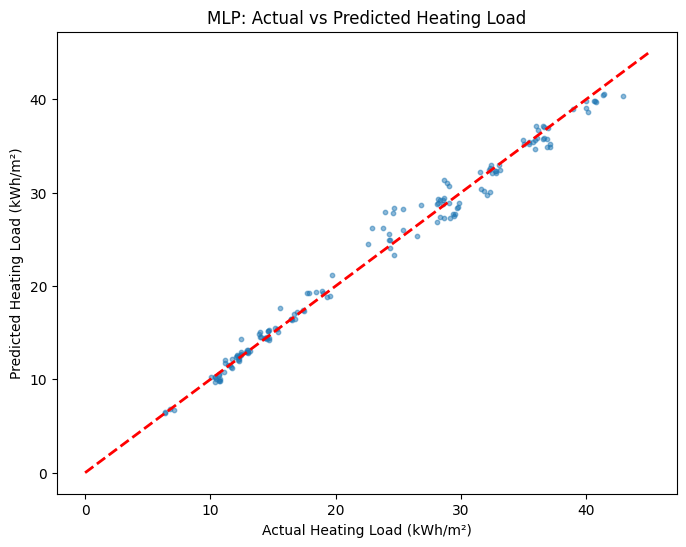

In [39]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test_y1, verbose=0)
print(f"MLP Test MAE: {test_mae:.4f} kWh/m²")

y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_y1, y_pred, alpha=0.5, s=10)
plt.plot([0, 45], [0, 45], 'r--', linewidth=2)
plt.xlabel('Actual Heating Load (kWh/m²)')
plt.ylabel('Predicted Heating Load (kWh/m²)')
plt.title('MLP: Actual vs Predicted Heating Load')
plt.show()

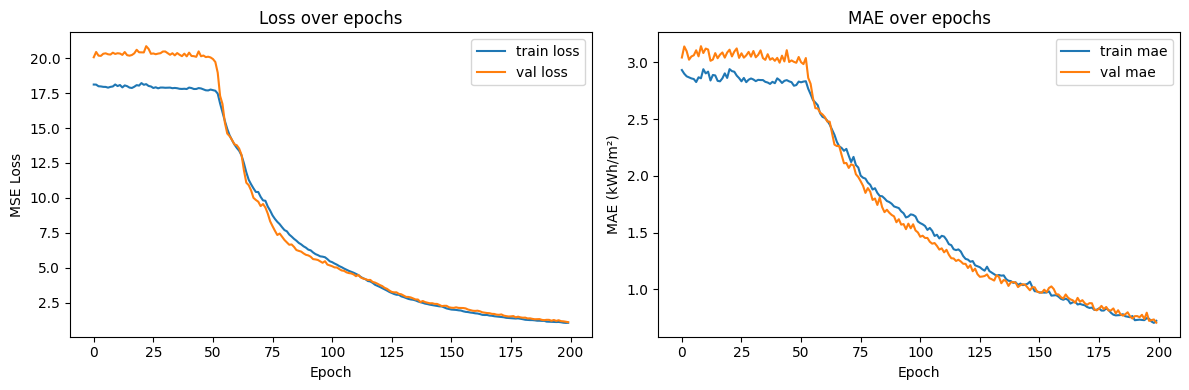

In [40]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss over epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='train mae')
plt.plot(history.history['val_mae'], label='val mae')
plt.xlabel('Epoch')
plt.ylabel('MAE (kWh/m²)')
plt.title('MAE over epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
no